In [1]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import math
import numpy as np
from qiskit.circuit.library import HGate
from qiskit.circuit.library import TGate
from qiskit.circuit.library import SGate
from qiskit.circuit.library import SwapGate
from os import error
from qiskit import transpile
from qiskit.visualization import plot_distribution

In [2]:
def QRC(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  qc.x(1)
  qc.x(2)

  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)
  qc.x(2)

  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  qc.barrier()


In [3]:
def Swap_Gate_Old(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  #qc.x(gate_control[0])
  #qc.x(swap_control[len(swap_control) - 1])

  #mc_swap = SwapGate().control(2)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 1], target[0], target[1]])

  #qc.x(gate_control[0])
  #qc.x(swap_control[len(swap_control) - 1])

  #qc.barrier()

  for j in range(int(math.pow(2, len(swap_control)))):
    for l in range(math.ceil(math.sqrt(n))):
      if(j % (2 ** l) == 0):
      #if((int(math.pow(2, len(swap_control) - 1)) - j - 1) % math.pow(2, l) == 0):
        qc.x(l+4)

    if(j >= n-1):
      continue

    controls = [swap_control[k] for k in range(math.ceil(math.sqrt(n+1)))]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j+1]])

  qc.barrier()

  #qc.x(gate_control[0])

  #mc_swap = SwapGate().control(2)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 1], target[0], target[1]])

  #qc.x(gate_control[0])

  qc.barrier()

In [4]:
def Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  #qc.x(gate_control[0])

  #mc_swap = SwapGate().control(3)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 2], swap_control[len(swap_control) - 1], target[0], target[1]])

  qc.barrier()

  for j in range(2 ** (len(swap_control) - 1)):
    for k in range(len(swap_control) - 1):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 1])

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control))]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])

  qc.barrier()

  #qc.x(swap_control[len(swap_control) - 1])

  #mc_swap = SwapGate().control(3)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 2], swap_control[len(swap_control) - 1], target[0], target[1]])

  #qc.x(gate_control[0])
  #qc.x(swap_control[len(swap_control) - 1])

  qc.barrier()

In [5]:
def Reverse_Swap_Gate_Old(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  for j in range(int(math.pow(2, len(swap_control) - 1))):
    for l in range(math.ceil(math.sqrt(n))):
      if(j % (2 ** l) == 0):
      #if((int(math.pow(2, len(swap_control) - 1)) - j - 1) % math.pow(2, l) == 0):
        qc.x(l+4)

    if(j >= n-1):
      continue

    controls = [swap_control[k] for k in range(math.ceil(math.sqrt(n+1)))] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j+1]])

  qc.barrier()

In [6]:
def Reverse_Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  for j in range(2 ** (len(swap_control) - 1)):
    for k in range(len(swap_control) - 1):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 1])

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control))] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])

  qc.barrier()

In [41]:
def Apply_Gate(qc):
  #Apply the Swap block
  Swap_Gate(qc)

  #Apply the QRC block
  QRC(qc)

  #Apply the Reverse Swap block
  Reverse_Swap_Gate(qc)

  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1

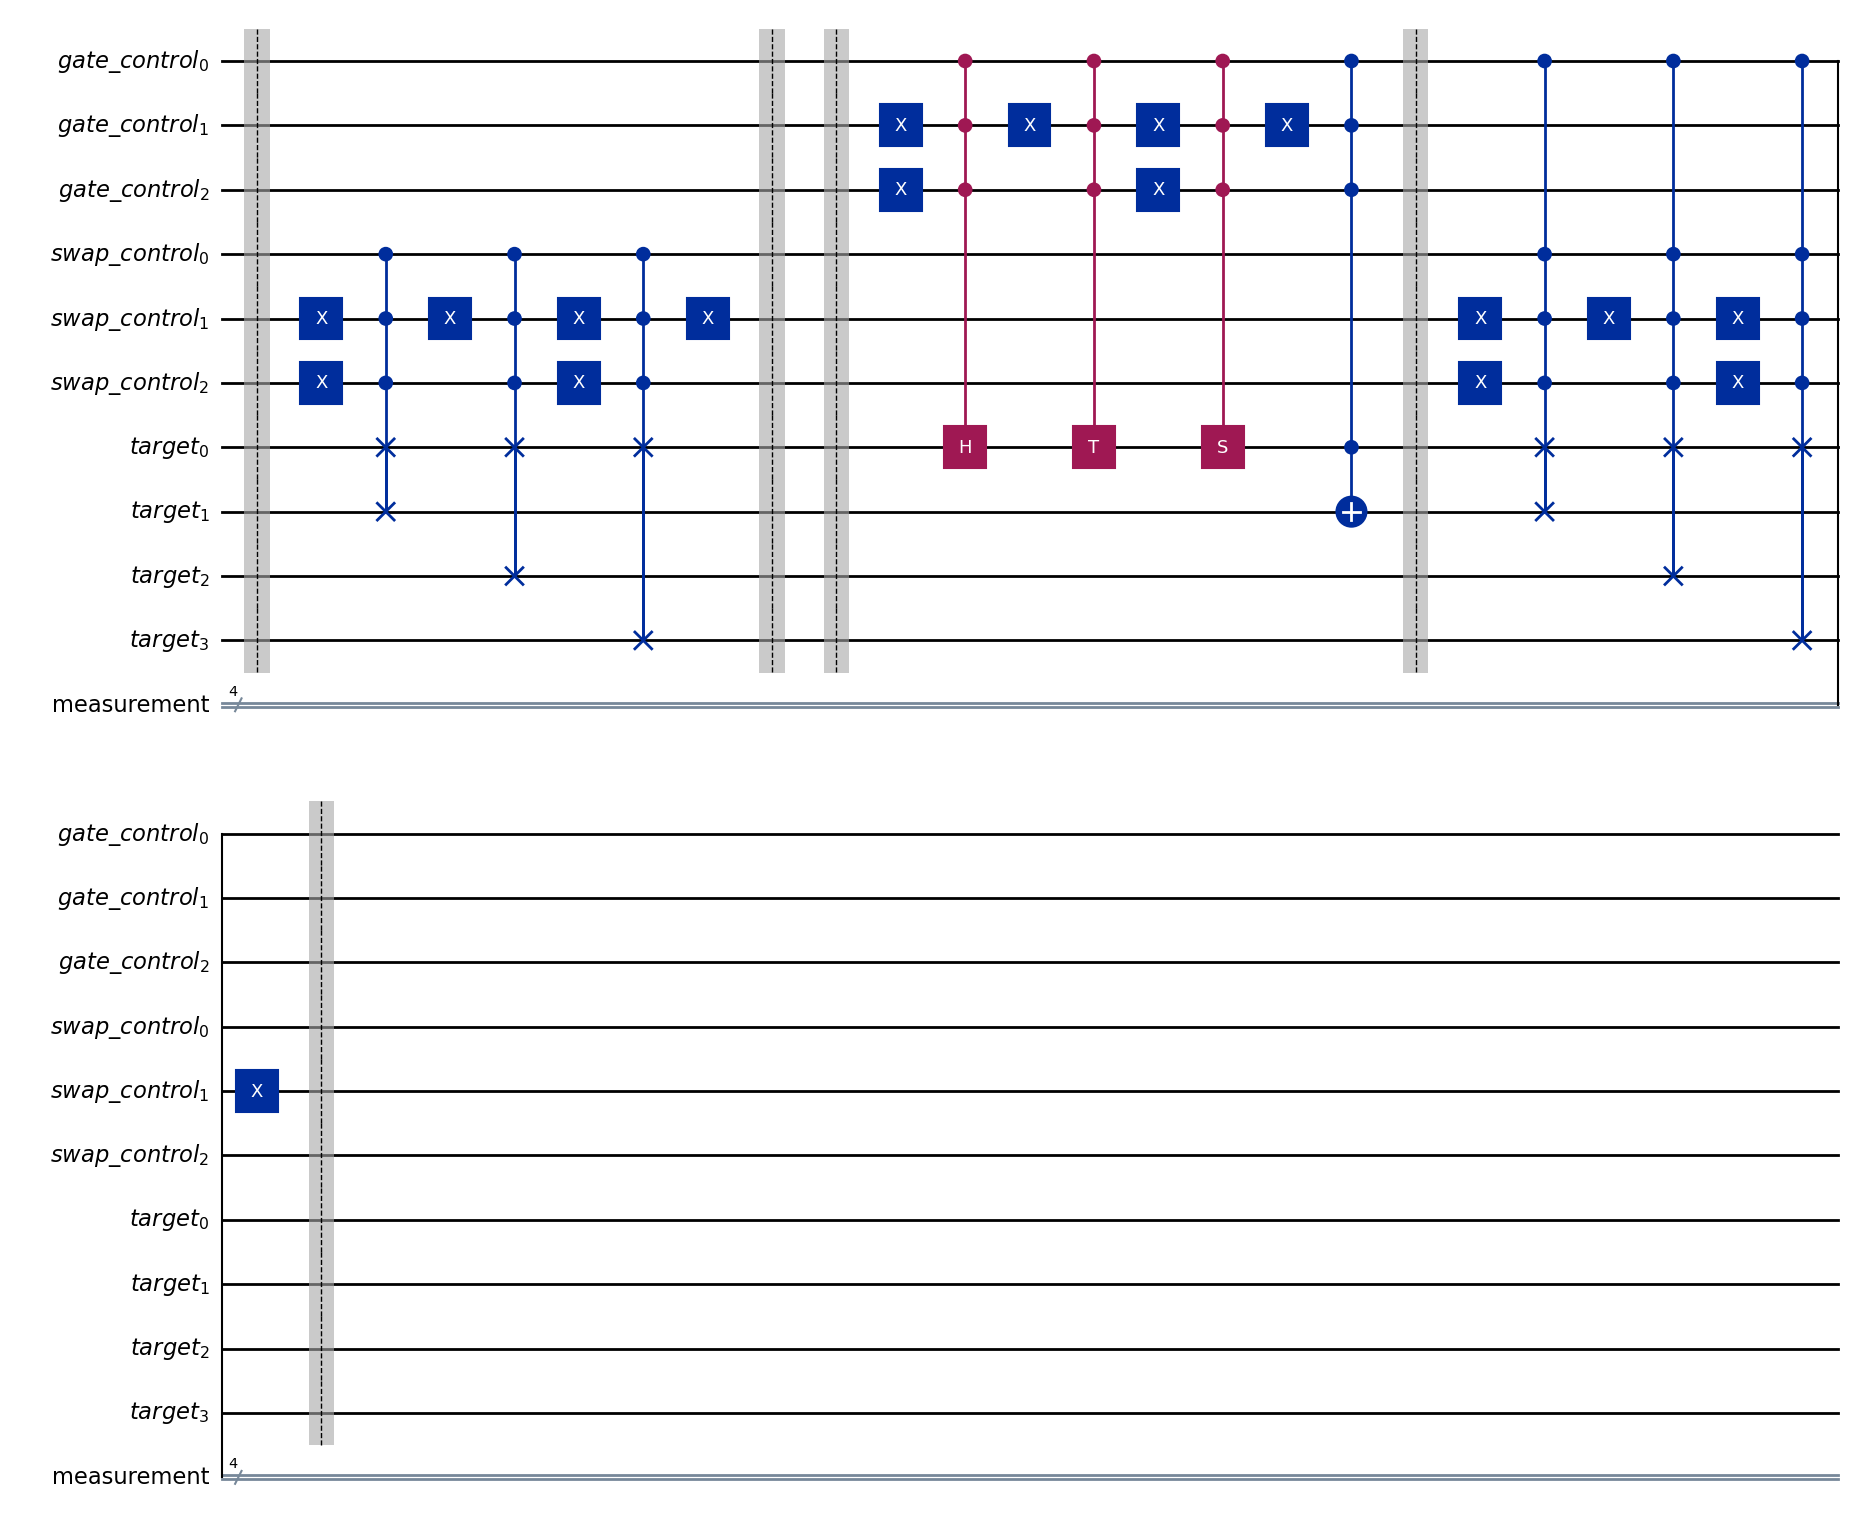

In [8]:
n = 4

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n - 1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

Apply_Gate(qc)

qc.draw(output="mpl")

In [9]:
def Modify_Swap_Control_Bits(qc, target_qubit):
  swap_control = qc.qregs[1]

  if(target_qubit == 0):
    qc.x(swap_control[0])
    return

  number_of_bits = len(swap_control) - 2
  binary = format(target_qubit - 1, f'0{number_of_bits}b')

  bit_id = 0

  for bit in reversed(binary):
    bit_id = bit_id + 1
    if bit == '1':
      qc.x(swap_control[bit_id])

In [10]:
def NOP_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  #Apply X on gate qubits
  qc.x(gate_control[0])

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Restore gate qubits
  qc.x(gate_control[0])

In [11]:
def H_Gate(qc, target_qubit):
  swap_control = qc.qregs[1]

  #Apply X on gate qubits
  #Nothing to do for H Gate

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  #Nothing to do for H Gate

In [12]:
def T_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  #Apply X on gate qubits
  qc.x(gate_control[1])

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])

In [13]:
def S_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  #Apply X on gate qubits
  qc.x(gate_control[2])

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[2])

In [14]:
def CNOT_Gate(qc, control_qubit, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")

  #if we want to apply CNOT with target on the second position, we don't have to make the NOP to move the target,
  #due to it already being in the correct position
  if(target_qubit != 1):
    #if the control qubit is on the first position, than after the swaps made on the target qubit it will be left
    #in the place of the target qubit and we need to adjust the value of the control qubit to know which qubit
    #needs to be swapped back to the first position
    if(control_qubit == 0):
      control_qubit = target_qubit

    #if the control qubit is on the second position, than after the swaps made on the target qubit it will be left
    #on the first position and we need to adjust the value of the control qubit to know which qubit needs to be
    #swapped back to the first position
    if(control_qubit == 1):
      control_qubit = 0

    #Apply NOP to move target qubit to the first position
    NOP_Gate(qc, target_qubit)

    #Apply NOP to move target to the second position
    NOP_Gate(qc, 1)

  #Apply CNOT gate
  #Apply X on gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])

  #Apply X on swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])

  if(target_qubit != 1):
    #Apply NOP to move target back to the first position
    NOP_Gate(qc, 1)

    #Apply NOP to move target back to the original position
    NOP_Gate(qc, target_qubit)

In [15]:
def CNOT_Gate_v2(qc, control_qubit, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")

  #Apply NOP to move control qubit to the second position if not already on second position
  if(target_qubit != 1):
    #if the control qubit is on the first position, than after the swaps made on the target qubit it will be left
    #in the place of the target qubit and we need to adjust the value of the control qubit to know which qubit
    #needs to be swapped back to the first position
    if(control_qubit == 0):
      control_qubit = target_qubit

    #if the control qubit is on the second position, than after the swaps made on the target qubit it will be left
    #on the first position and we need to adjust the value of the control qubit to know which qubit needs to be
    #swapped back to the first position
    if(control_qubit == 1):
      control_qubit = 0
      

    NOP_Gate(qc, target_qubit)

  #Apply CNOT gate
  #Apply X on gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])

  #Apply X on swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])

  #Apply NOP to move control back to the original position if it is not already in initial position
  if(target_qubit != 1):
    qc.x(swap_control[len(swap_control) - 1])
    NOP_Gate(qc, target_qubit)
    qc.x(swap_control[len(swap_control) - 1])

In [16]:
def Z_Gate(qc, target_qubit):
  S_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)

In [17]:
def X_Gate(qc, target_qubit):
  H_Gate(qc, target_qubit)
  Z_Gate(qc, target_qubit)
  H_Gate(qc, target_qubit)

In [18]:
def T_Dagger_Gate(qc, target_qubit):
  Z_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)
  T_Gate(qc, target_qubit)

In [19]:
def Toffoli_Gate(qc, control_qubit_1, control_qubit_2, target_qubit):
  T_Dagger_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, control_qubit_2)
  H_Gate(qc, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  T_Gate(qc, target_qubit)

  T_Dagger_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  H_Gate(qc, target_qubit)

In [20]:
def Toffoli_Gate_3(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)

In [21]:
def Toffoli_Gate_4(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)

In [22]:
def Toffoli_Gate_5(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [23]:
def Toffoli_Gate_6(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [24]:
def Toffoli_Gate_7(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [25]:
def Toffoli_Gate_8(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [26]:
def Reconfigurable_Oracle(qc, target_value):
  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

  match len(target_value):
    case 3:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 4)
    case 4:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 5)
    case 5:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 6)
    case 6:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 7)
    case 7:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 8)
    case 8:
      Toffoli_Gate_8(qc, [0, 1, 2, 3, 4, 5, 6, 7], 8, 9)

  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

In [27]:
def Reconfigurable_Diffuser(qc):
  n = len(qc.qregs[2]) - 2

  for i in range(n):
    H_Gate(qc, i)
    X_Gate(qc, i)

  H_Gate(qc, n-1)

  match n:
    case 2:
      CNOT_Gate(qc, 0, 1)
    case 3:
      Toffoli_Gate(qc, 0, 1, 2)
    case 4:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 5)
    case 5:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 6)
    case 6:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 7)
    case 7:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 8)
    case 8:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 9)

  H_Gate(qc, n-1)

  for i in range(n):
    X_Gate(qc, i)
    H_Gate(qc, i)

In [49]:
#target_value = "110"
#target_value = "1101"
#target_value = "11010"
#target_value = "110100"
#target_value = "1101001"
target_value = "11010010"

n = len(target_value)

gate_control = QuantumRegister(3, "gate_control")
#swap_control = QuantumRegister(n+1+1, "swap_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n+1)), "swap_control")
target = QuantumRegister(n+1+1, "target")
measurement = ClassicalRegister(n+1+1, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

reconfigurable_cell_count = 0

qc.x(gate_control[0])
qc.x(swap_control[0])

#Start

X_Gate(qc, n)

for i in range(n+1):
  H_Gate(qc, i)

steps = math.sqrt(math.pow(2,n))
steps = round(math.pi/4 * steps)

print(steps)

for i in range(steps):
  Reconfigurable_Oracle(qc, target_value)
  Reconfigurable_Diffuser(qc)

#Reconfigurable_Oracle(qc, target_value)
#Reconfigurable_Diffuser(qc)
#Reconfigurable_Oracle(qc, target_value)
#Reconfigurable_Diffuser(qc)

H_Gate(qc, n)
X_Gate(qc, n)

#End

#CNOT_Gate(qc, 2, 4)

qc.x(gate_control[0])
qc.x(swap_control[0])

qc.measure(target, range(n+1+1))

print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

#qc.draw("mpl")

13
reconfigurable_cell_count = 35144


{'0011010010': 1, '0001001011': 9869, '0000001101': 2, '0000110001': 1, '0000101111': 1, '0010101100': 1, '0010111100': 1, '0010001010': 2, '0011011010': 1, '0000000111': 3, '0011100010': 2, '0000110111': 2, '0010101001': 3, '0011001111': 1, '0011100100': 1, '0010101000': 1, '0001100000': 1, '0011110000': 1, '0000001010': 1, '0011000110': 1, '0011111001': 2, '0010111110': 2, '0000100101': 2, '0010010100': 2, '0011000010': 1, '0001001010': 1, '0000100111': 3, '0011010101': 2, '0010010010': 1, '0000100011': 2, '0000111101': 1, '0000101100': 1, '0000110100': 1, '0001000101': 2, '0000100000': 1, '0011101110': 4, '0010001101': 2, '0010111111': 1, '0001010011': 1, '0000111110': 1, '0000100010': 1, '0011000101': 3, '0000011101': 1, '0000010100': 2, '0010000001': 1, '0010110011': 1, '0011011101': 1, '0011111000': 1, '0001010001': 2, '0010101010': 1, '0010110001': 1, '0010000011': 1, '0000001001': 1, '0001111000': 1, '0010101011': 1, '0000010111': 2, '0010101111': 2, '0010111001': 1, '001010011

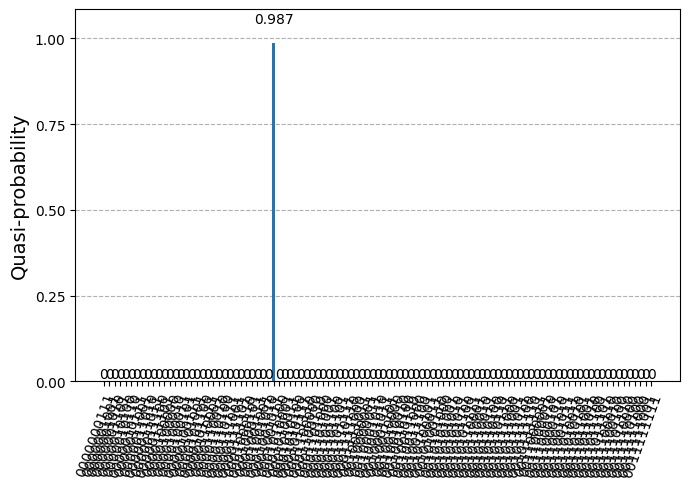

In [37]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

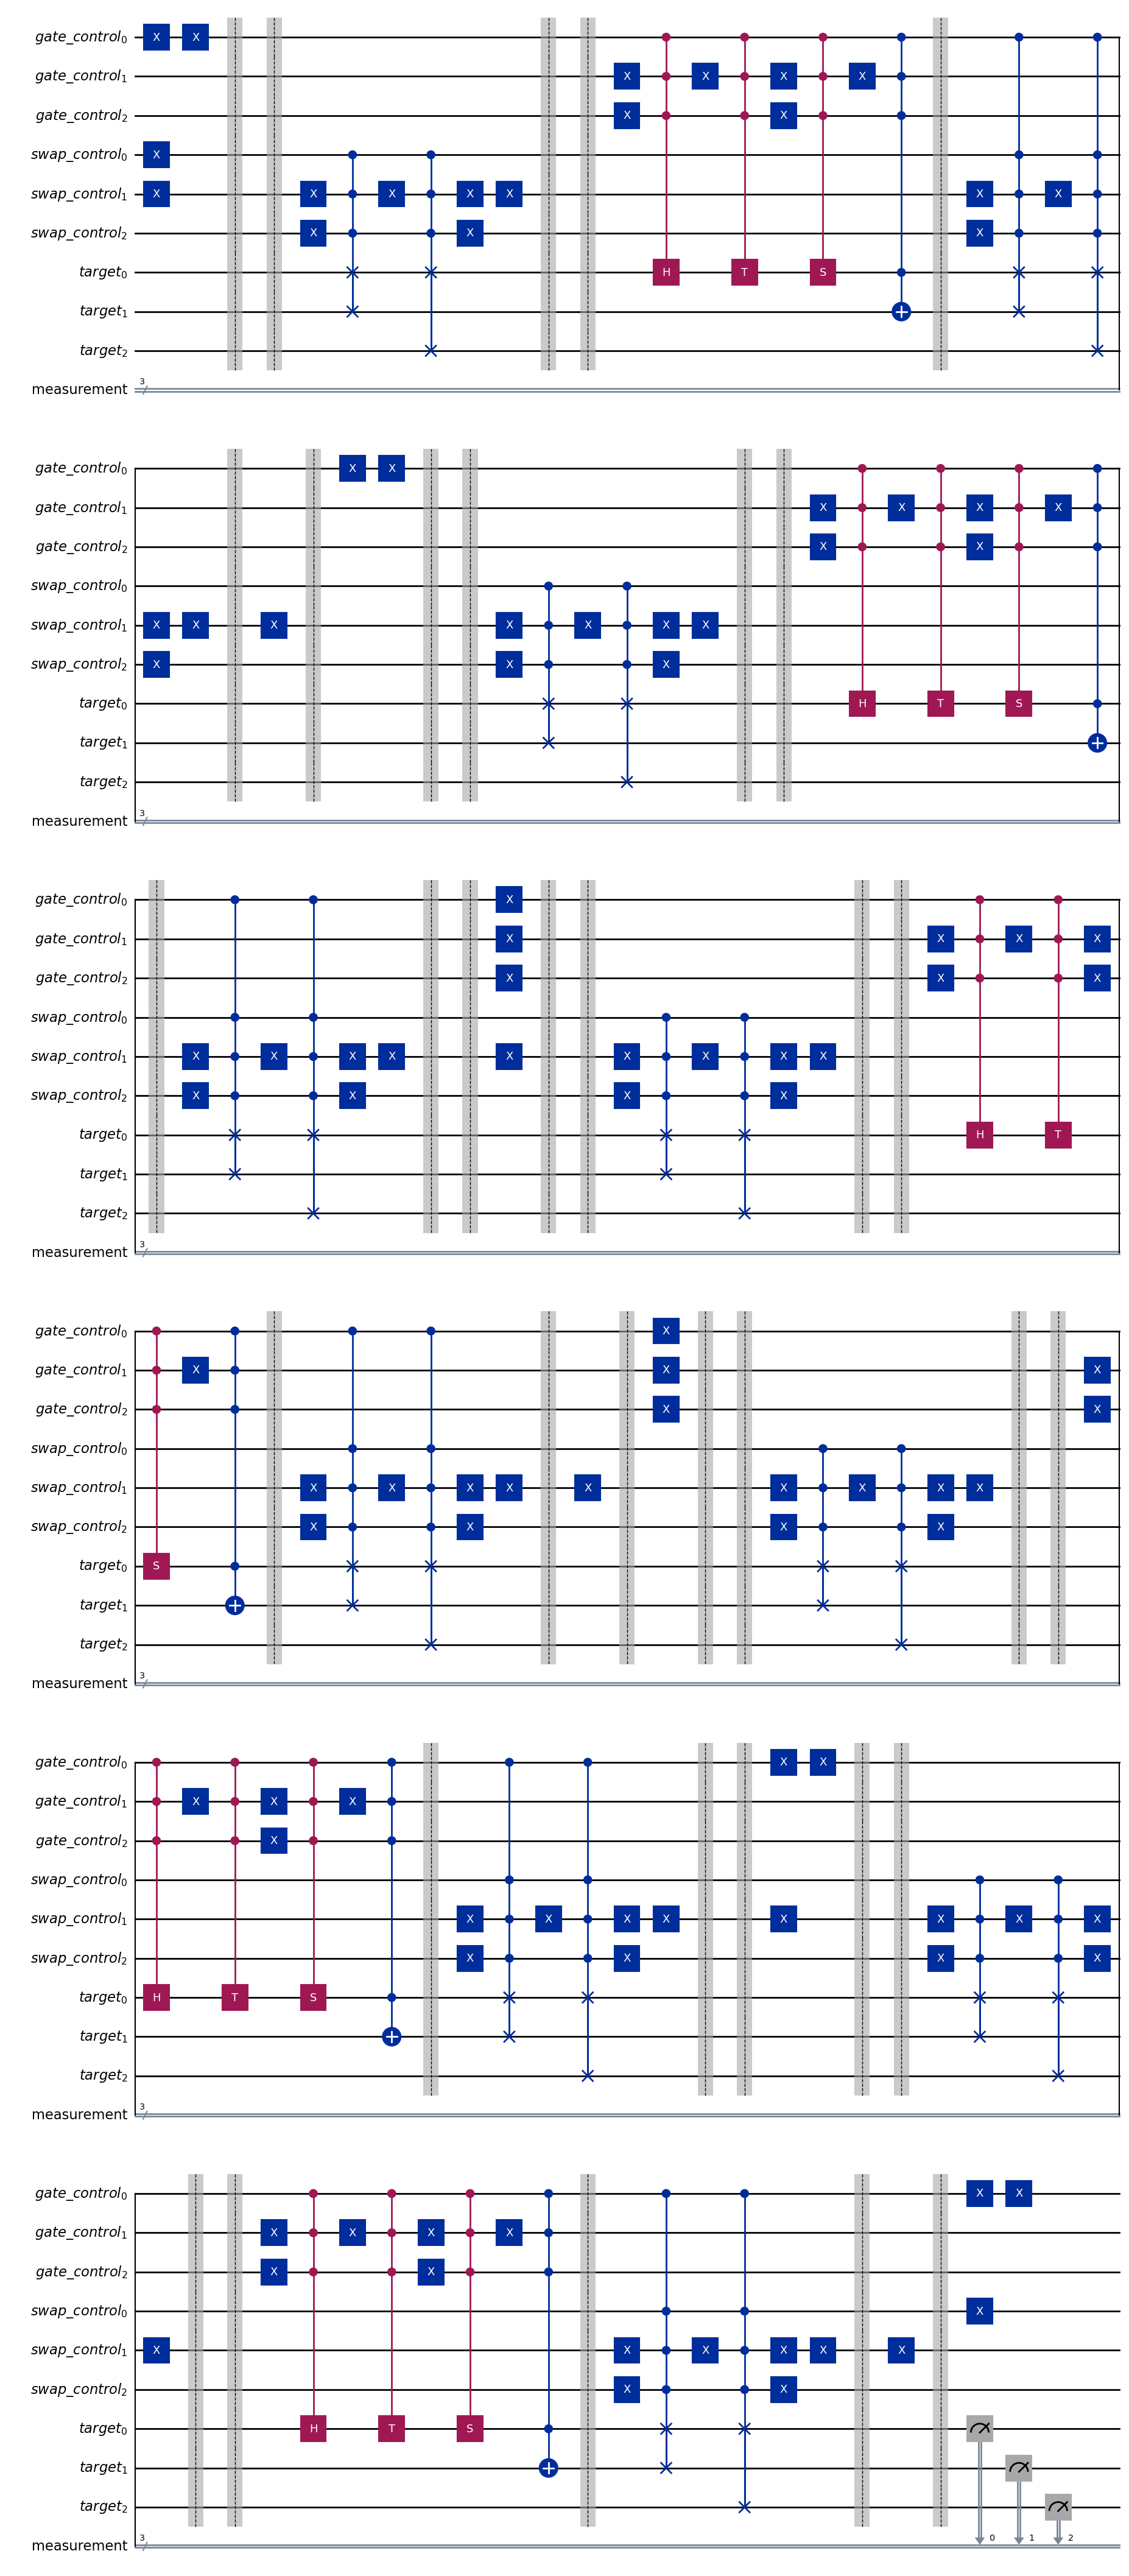

In [30]:
n = 3

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n-1) + 1), "swap_control")
#swap_control = QuantumRegister(1 + math.ceil(math.sqrt(n-1)) + 1, "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
qc.x(swap_control[0])

#H_Gate(qc, )
#H_Gate(qc, 2)

#X_Gate(qc, 0)
#X_Gate(qc, 1)
CNOT_Gate(qc, 0, 2)

#CNOT_Gate_v2(qc, 2, 3)
#CNOT_Gate_v2(qc, 2, 1)
#CNOT_Gate_v2(qc, 2, 0)

qc.measure(target, range(n))

qc.x(gate_control[0])
qc.x(swap_control[0])

qc.draw("mpl")

{'000': 10000}


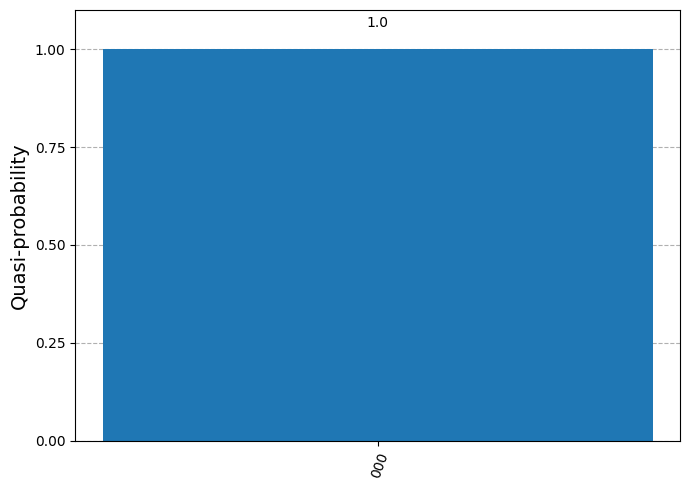

In [31]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

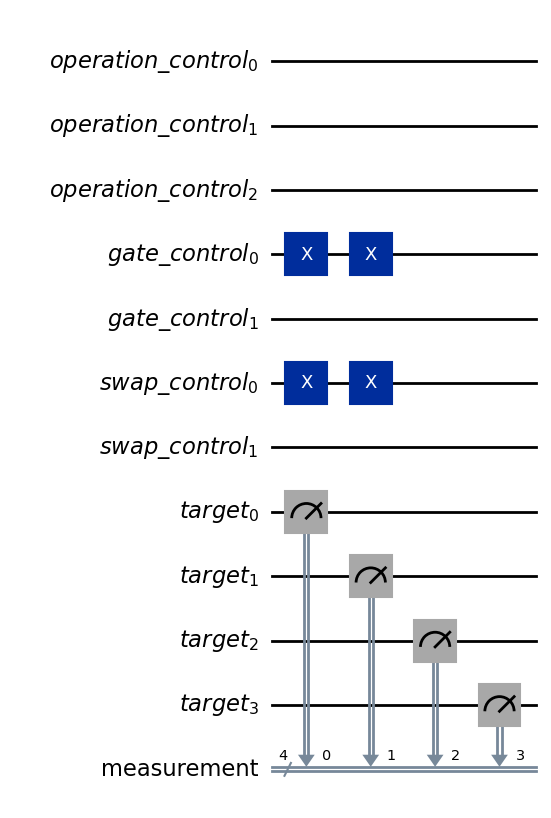

In [32]:
n = 4

operation_control = QuantumRegister(3, "operation_control")
#operations encoding:
#000 -> No operation
#110 -> R-CNOT SWAP
#x1x -> SWAP
#111 -> CNOT SWAP
#0x1 -> QRC
#011 -> R-SWAP

gate_control = QuantumRegister(2, "gate_control")
#gates encodings:
#00 H Gate
#01 T Gate
#10 S Gate
#11 CNOT Gate

swap_control = QuantumRegister(math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

qc = QuantumCircuit(operation_control, gate_control, swap_control, target, measurement)


qc.x(gate_control[0])
qc.x(swap_control[0])

qc.measure(target, range(n))

qc.x(gate_control[0])
qc.x(swap_control[0])

qc.draw("mpl")

In [33]:
def R_CNOT_Swap_v2(qc):
  operation_control = qc.qregs[0]
  target = qc.qregs[3]

  qc.x(operation_control[0])

  mc_swap = SwapGate().control(3)
  qc.append(mc_swap, [operation_control[0], operation_control[1], operation_control[2], target[0], target[1]])

  qc.x(operation_control[0])

  qc.barrier()

In [34]:
def Swap_Gate_v2(qc): #work in progress
  operation_control = qc.qregs[0]
  gate_control = qc.qregs[1]
  swap_control = qc.qregs[2]
  target = qc.qregs[3]
  n = len(target)

  for j in range(int(math.pow(2, len(swap_control) - 1))):
    for l in range(math.ceil(math.sqrt(n))):
      if(j % (2 ** l) == 0):
      #if((int(math.pow(2, len(swap_control) - 1)) - j - 1) % math.pow(2, l) == 0):
        qc.x(l+4)

    if(j >= n-1):
      continue

    controls = [swap_control[k] for k in range(math.ceil(math.sqrt(n+1)))]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j+1]])

  qc.barrier()

  #qc.x(gate_control[0])

  #mc_swap = SwapGate().control(2)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 1], target[0], target[1]])

  #qc.x(gate_control[0])

  qc.barrier()

In [35]:
def QRC_v2(qc): #work in progress
  operation_control = qc.qregs[0]
  gate_control = qc.qregs[1]
  target = qc.qregs[3]

  qc.x(1)
  qc.x(2)

  c3h_gate = HGate().control(4)
  qc.append(c3h_gate, [operation_control[0], operation_control[2], gate_control[0], gate_control[1],target[0]])

  qc.x(1)

  t3h_gate = TGate().control(4)
  qc.append(t3h_gate, [operation_control[0], operation_control[2], gate_control[1], gate_control[2], target[0]])

  qc.x(1)
  qc.x(2)

  s3h_gate = SGate().control(4)
  qc.append(s3h_gate, [operation_control[0], operation_control[2], gate_control[1], gate_control[2], target[0]])

  qc.x(1)

  qc.mcx([operation_control[0], operation_control[2], gate_control[1], gate_control[2], target[0]],target[1])

  qc.barrier()